# 02 · Zero-shot amenity detection with OWL-ViT

[OWL-ViT](https://huggingface.co/google/owlvit-base-patch16) detects objects
described by text, with no fine-tuning and no training data. You give it an
image and a list of phrases; it returns boxes and scores.

That property is what makes the whole project tractable: adding a new amenity
costs a line of YAML, not an annotation campaign.

```
image ──► OWL-ViT(text prompts) ──► boxes + scores
                                        │
                     confidence sweep ──┤
                                        ▼
              greedy IoU matching vs COCO ground truth
                                        │
                                        ▼
                    precision · recall · F1 · mean IoU
```

Inference runs **once** at a permissive threshold (0.05). The sweep then filters
those saved detections, so exploring 10 thresholds costs no additional GPU time.
Structuring it that way is why the full sweep was affordable at all.

Scoring applies class-agnostic NMS, then matches predictions one-to-one against
ground truth in descending confidence order, so several boxes on the same object
count once rather than several times. `tests/test_metrics.py` asserts the
invariant that makes this checkable: `tp + fn` always equals the ground-truth box
count, at every threshold and for every prompt set.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 90)

SAMPLE = REPO_ROOT / "data" / "sample"
RESULTS = REPO_ROOT / "results"
print("Repository root:", REPO_ROOT.name)


Repository root: portfolio-clean


In [2]:
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

# Photographs re-encode as PNG in notebook output, which is what drives .ipynb
# file size. 72 dpi keeps the committed notebooks light enough to render quickly
# on GitHub while staying perfectly legible.
plt.rcParams["figure.dpi"] = 72


def load_sample_coco(amenity):
    """Ground-truth boxes for the committed sample, keyed by file name."""
    coco = json.loads((SAMPLE / amenity / "_annotations.coco.json").read_text())
    by_id = {i["id"]: i["file_name"] for i in coco["images"]}
    boxes = {}
    for ann in coco["annotations"]:
        x, y, w, h = ann["bbox"]
        boxes.setdefault(by_id[ann["image_id"]], []).append([x, y, x + w, y + h])
    return coco, boxes


def show_detections(amenity, file_names, detections, gt_boxes, conf, ncols=3):
    """Green = ground truth, orange = detection above `conf`."""
    nrows = (len(file_names) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.2 * nrows))
    axes = axes.ravel() if hasattr(axes, "ravel") else [axes]

    for ax, name in zip(axes, file_names):
        ax.imshow(Image.open(SAMPLE / amenity / name).convert("RGB"))
        for x1, y1, x2, y2 in gt_boxes.get(name, []):
            ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                                   fill=False, edgecolor="#2E9B57", linewidth=2.5))
        hits = detections[(detections["image"] == name) & (detections["score"] > conf)]
        for _, d in hits.iterrows():
            ax.add_patch(Rectangle((d.x1, d.y1), d.x2 - d.x1, d.y2 - d.y1,
                                   fill=False, edgecolor="#E07B39", linewidth=2.0,
                                   linestyle="--"))
            ax.text(d.x1, max(d.y1 - 6, 10), f"{d.score:.2f}", color="#E07B39",
                    fontsize=9, fontweight="bold")
        n_gt = len(gt_boxes.get(name, []))
        ax.set_title(f"{n_gt} ground truth · {len(hits)} detected", fontsize=9)
        ax.axis("off")

    for ax in axes[len(file_names):]:
        ax.axis("off")
    fig.suptitle("green = ground truth    orange dashed = OWL-ViT detection",
                 fontsize=10, y=1.005)
    plt.tight_layout()
    plt.show()


In [3]:
from src.config import load_config

configs = load_config()
print("Amenities configured:", ", ".join(configs))

Amenities configured: bathtub, hairdryer, kettle, mirror, tv


## Optionally: run the detector live

Everything below this cell reads the **committed** detection CSVs from the
original full-scale runs. If you want to watch OWL-ViT actually work, set the
flag and re-run. It will detect over the 10 committed bathtub sample images.

It is off by default because the model weights are a ~600 MB download, and
because the committed results are what the reported numbers are based on.

In [4]:
RUN_LIVE_DETECTION = False   # set True to run OWL-ViT on data/sample/bathtub

if RUN_LIVE_DETECTION:
    from src.detection.detector import OwlViTDetector

    detector = OwlViTDetector()                       # picks cuda / mps / cpu
    paths = sorted((SAMPLE / "bathtub").glob("*.jpg"))
    live = detector.detect_folder(
        paths,
        prompts=configs["bathtub"].prompt_sets["baseline"],
        threshold=0.05,
    )
    print(f"{len(live)} detections over {len(paths)} sample images")
    display(live.head())
else:
    print("Live detection skipped. The cells below use the committed detection CSVs.")
    print("Set RUN_LIVE_DETECTION = True to run OWL-ViT over data/sample/bathtub.")

Live detection skipped. The cells below use the committed detection CSVs.
Set RUN_LIVE_DETECTION = True to run OWL-ViT over data/sample/bathtub.


## Real detections on real images

These boxes are from the committed results of the original run, not
regenerated. Green is ground truth, orange dashed is what OWL-ViT found at the
threshold that maximised F1 for this amenity.

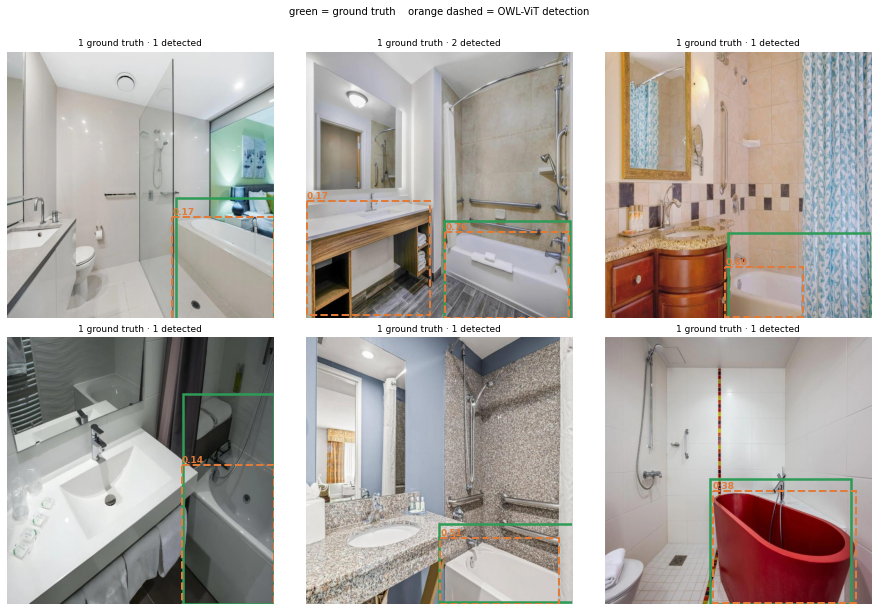

In [5]:
detections = pd.read_csv(RESULTS / "detection_outputs" / "bathtub" / "dets_bathtub_baseline.csv")
coco, gt = load_sample_coco("bathtub")

with_gt = [i["file_name"] for i in coco["images"] if i["file_name"] in gt][:6]
show_detections("bathtub", with_gt, detections, gt, conf=0.05)

Two things are visible here that a metric table cannot show you: the detector
often finds the object but draws a looser box than the annotator did, and it
sometimes fires twice on one tub. Both depress IoU without meaning the detection
was useless.

## The confidence sweep

For one amenity and one prompt set, every threshold from 0.05 to 0.50.

In [6]:
from src.detection.metrics import best_per_prompt, load_summary

summary = load_summary(RESULTS / "detection_metrics" / "bathtub" / "summary_bathtub.csv")
summary[summary["prompt"] == "baseline"].sort_values("conf")[
    ["prompt", "conf", "precision", "recall", "f1", "mean_iou"]
]

,prompt,conf,precision,recall,f1,mean_iou
0,baseline,0.05,0.718147,0.861111,0.783158,0.776626
1,baseline,0.15,0.806283,0.712963,0.756757,0.778425
2,baseline,0.25,0.885965,0.467593,0.612121,0.784335
3,baseline,0.35,0.929577,0.305556,0.459930,0.776480
4,baseline,0.45,0.942857,0.152778,0.262948,0.764419


## Finding 1: richer prompts mostly did not help

Best row per prompt set, all five amenities.

In [7]:
rows = []
for key, cfg in configs.items():
    s = load_summary(RESULTS / "detection_metrics" / key / f"summary_{key}.csv")
    for _, best in best_per_prompt(s).iterrows():
        rows.append({
            "amenity": cfg.display_name,
            "prompt set": best["prompt"],
            "conf": best["conf"],
            "f1": round(best["f1"], 3),
        })

comparison = pd.DataFrame(rows).pivot(index="amenity", columns="prompt set", values="f1")
comparison

prompt set,baseline,electric,hybrid,long,rich_phrase,variants
amenity,,,,,,
Bathtub,0.783,NaN,NaN,0.660,NaN,0.706
Hairdryer,0.770,NaN,NaN,0.441,NaN,0.778
Kettle,0.692,0.696,NaN,NaN,0.694,0.689
Mirror,0.667,NaN,0.649,0.546,NaN,0.630
TV,0.832,NaN,NaN,0.713,NaN,0.782


In [8]:
winners = comparison.idxmax(axis=1).value_counts()
print("Winning prompt set, by amenity:")
print(winners.to_string())
print()
if "long" in comparison.columns:
    gap = (comparison["baseline"] - comparison["long"]).dropna()
    print(f"baseline beats long on {(gap > 0).sum()} of {len(gap)} amenities "
          f"(mean F1 gap {gap.mean():+.3f})")

Winning prompt set, by amenity:
baseline    3
variants    1
electric    1

baseline beats long on 4 of 4 amenities (mean F1 gap +0.173)


The bare class name wins for bathtub, mirror and TV, and the long descriptive
prompt is the *worst* option in every case. Hairdryer improves with multiple
synonyms, which makes sense, since "hairdryer", "hair dryer" and "blow dryer" are
genuinely different strings for the same object. Kettle is a tie inside the
noise.

The likely reason the long prompts hurt: OWL-ViT's text encoder embeds the whole
phrase, so "white ceramic bathtub in a hotel bathroom" is not a sharper bathtub
query. It is a different, more diffuse one, pulled toward whatever "hotel" and
"ceramic" mean in embedding space.

**Prompt engineering is not a free lunch for open-vocabulary detection.**

## Finding 2: the best threshold is far lower than any sensible default

In [9]:
best = []
for key, cfg in configs.items():
    s = load_summary(RESULTS / "detection_metrics" / key / f"summary_{key}.csv")
    top = best_per_prompt(s).sort_values("f1", ascending=False).iloc[0]
    best.append({
        "amenity": cfg.display_name,
        "best prompt": top["prompt"],
        "conf": top["conf"],
        "precision": round(top["precision"], 3),
        "recall": round(top["recall"], 3),
        "f1": round(top["f1"], 3),
        "mean IoU": round(top["mean_iou"], 3),
    })

headline = pd.DataFrame(best).sort_values("f1", ascending=False)
headline

,amenity,best prompt,conf,precision,recall,f1,mean IoU
4,TV,baseline,0.05,0.885,0.785,0.832,0.849
0,Bathtub,baseline,0.05,0.718,0.861,0.783,0.777
1,Hairdryer,variants,0.15,0.827,0.735,0.778,0.762
2,Kettle,electric,0.05,0.735,0.662,0.696,0.783
3,Mirror,baseline,0.15,0.667,0.667,0.667,0.844


In [10]:
n_low = (headline["conf"] <= 0.05).sum()
print(f"{n_low} of {len(headline)} amenities peak at conf = 0.05, "
      f"{(headline['conf'] <= 0.15).sum()} at 0.15 or below")
print(f"Mean best F1 {headline['f1'].mean():.3f}  "
      f"(range {headline['f1'].min():.3f}–{headline['f1'].max():.3f})")

# What a conventional threshold would have cost, computed rather than asserted.
import statistics

for target in (0.25, 0.35):
    at_conf = []
    for key, cfg in configs.items():
        s = load_summary(RESULTS / "detection_metrics" / key / f"summary_{key}.csv")
        best_prompt = s.sort_values("f1", ascending=False).iloc[0]["prompt"]
        rows = s[(s["prompt"] == best_prompt) & (s["conf"].between(target - 0.01, target + 0.01))]
        if not rows.empty:
            at_conf.append(rows.iloc[0]["f1"])
    if at_conf:
        print(f"Mean F1 at conf {target:.2f}: {statistics.mean(at_conf):.3f}")

print(f"Mean F1 at the swept optimum: {headline['f1'].mean():.3f}")

3 of 5 amenities peak at conf = 0.05, 5 at 0.15 or below
Mean best F1 0.751  (range 0.667–0.832)
Mean F1 at conf 0.25: 0.540
Mean F1 at conf 0.35: 0.333
Mean F1 at the swept optimum: 0.751


Every amenity peaks at 0.15 or below, most at 0.05. These are small, frequently
occluded objects in cluttered rooms, and OWL-ViT is systematically
*underconfident* about them. Mean F1 falls from 0.751 at the swept optimum to
0.540 at 0.25 and 0.333 at 0.35. Anyone who deployed this at a conventional
threshold would have concluded the approach does not work.

That is the practical lesson worth carrying out of this project: for
open-vocabulary detection on a new domain, the threshold is not a
hyperparameter to leave at its default. It is the first thing to measure.

![F1 across prompt sets and thresholds](../results/figures/bathtub/prompt_comparison_full.png)

## The cost side: false positives on negative images

F1 on positive images says nothing about how often the detector invents an
amenity that is not there. Those images are scored separately.

In [11]:
negatives = pd.read_csv(
    RESULTS / "detection_metrics" / "bathtub" / "negatives_bathtub.csv",
    encoding="utf-8-sig",
)
negatives

,conf,fpr,specificity,false_images,mean_conf
0,0.05,0.263158,0.736842,20,0.173411
1,0.15,0.118421,0.881579,9,0.232630
2,0.25,0.039474,0.960526,3,0.324393
3,0.35,0.026316,0.973684,2,0.374248
4,0.45,0.000000,1.000000,0,0.000000


And there is the trade-off, stated plainly: **the low threshold that maximises
F1 is also the threshold with the weakest specificity.** A production system
would not pick one number for all five amenities. It would tune each one against
the cost of showing a traveller a question about a bathtub that does not exist,
which is a product decision, not a modelling one.